# Realised Volatility Regime Mean Reversion Walk-Forward Backtest

**Strategy:** Fade extreme realised volatility regimes on Hyperliquid BTC perpetuals.
When 24-hour realised volatility spikes into the HIGH regime, price has moved aggressively
in one direction. Mean reversion theory validated in the IV regime dashboard research
predicts this extreme directional move will partially reverse. We fade it.

**Direct connection to prior research:**
- IV Regime Dashboard: high volatility regimes mean revert 30-40% faster than low vol regimes
- HMM Dashboard: bar volatility classifies market into LOW/MED/HIGH regimes via Bayesian inference
- fBm Research: H < 0.5 confirms anti-persistent mean-reverting regime

**Three versions tested:**
- Version 1: Realised volatility signal only (baseline)
- Version 2: Realised volatility + HMM regime filter
- Version 3: Realised volatility + HMM + Hurst exponent filter

**Walk-forward methodology:**
- Train window: 30 days (threshold calibration)
- Test window: 10 days (out-of-sample simulation)
- 6 months of data across BTC, ETH, SOL
- No look-ahead bias

---

In [1]:
# =============================================================================
# SETUP — same as funding rate backtest
# =============================================================================
import subprocess
subprocess.run(['pip', 'install', 'yfinance'], capture_output=True)

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
from scipy import stats
import yfinance as yf
import time as time_module
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
BLUE   = '#58a6ff'
RED    = '#f85149'
GREEN  = '#7ee787'
YELLOW = '#d29922'
GREY   = '#8b949e'

HYPERLIQUID_API = 'https://api.hyperliquid.xyz/info'
print('Setup complete')

Setup complete


## 1. Data Fetching

Fetch 6 months of hourly price data via paginated Hyperliquid candle requests.
Same stitching approach as the funding rate backtest — multiple requests to overcome the 500-row API limit.

In [2]:
# =============================================================================
# FETCH 6 MONTHS OF HOURLY CANDLES — PAGINATED
# =============================================================================

def fetch_candle_history(coin: str = 'BTC', months: int = 6) -> pd.DataFrame:
    """
    Fetch full hourly OHLCV history from Hyperliquid by paginating backwards.
    Hyperliquid returns max ~500 candles per request.
    Same stitching approach as fetch_full_history() in the funding rate backtest.
    
    Returns DataFrame with OHLCV + log_return columns.
    """
    all_candles = []
    total_days  = months * 30
    # Each request covers roughly 20 days of hourly candles
    requests_needed = int(np.ceil(total_days / 20)) + 1
    
    print(f"Fetching {total_days} days of {coin} hourly candles ({requests_needed} requests)...")
    
    current_end = datetime.now()
    
    for i in range(requests_needed):
        start    = current_end - timedelta(days=21)
        start_ms = int(start.timestamp() * 1000)
        end_ms   = int(current_end.timestamp() * 1000)
        
        payload = {
            'type': 'candleSnapshot',
            'req': {
                'coin':      coin,
                'interval':  '1h',
                'startTime': start_ms,
                'endTime':   end_ms
            }
        }
        
        try:
            response = requests.post(HYPERLIQUID_API, json=payload, timeout=15)
            response.raise_for_status()
            data = response.json()
            
            if not data:
                print(f"  Batch {i+1}: empty, stopping")
                break
            
            all_candles.extend(data)
            
            # Parse first candle to get earliest timestamp
            if isinstance(data[0], dict):
                earliest_ms = data[0].get('t', data[0].get('time', start_ms))
            else:
                earliest_ms = data[0][0]
            
            earliest = pd.to_datetime(earliest_ms, unit='ms')
            current_end = earliest - timedelta(hours=1)
            print(f"  Batch {i+1}: {len(data)} candles, back to {earliest.date()}")
            
        except Exception as e:
            print(f"  Batch {i+1} failed: {e}")
            break
        
        time_module.sleep(0.5)
    
    if not all_candles:
        print(f"No candle data for {coin}, falling back to yfinance...")
        return fetch_candles_yfinance(coin, months)
    
    # Parse candles — handle both dict and list formats
    rows = []
    for c in all_candles:
        if isinstance(c, dict):
            rows.append({
                'time':   c.get('t', c.get('time')),
                'open':   float(c.get('o', c.get('open',  0))),
                'high':   float(c.get('h', c.get('high',  0))),
                'low':    float(c.get('l', c.get('low',   0))),
                'close':  float(c.get('c', c.get('close', 0))),
                'volume': float(c.get('v', c.get('volume',0)))
            })
        else:
            rows.append({
                'time':   c[0], 'open':  float(c[1]),
                'high':   float(c[2]), 'low':   float(c[3]),
                'close':  float(c[4]), 'volume':float(c[5])
            })
    
    df = pd.DataFrame(rows)
    df['time'] = pd.to_datetime(df['time'], unit='ms')
    df = df.drop_duplicates('time').sort_values('time').reset_index(drop=True)
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    
    print(f"Total: {len(df)} hourly candles, {df.time.min().date()} to {df.time.max().date()}")
    return df


def fetch_candles_yfinance(coin: str, months: int) -> pd.DataFrame:
    """Fallback: fetch hourly candles from yfinance."""
    ticker_map = {'BTC': 'BTC-USD', 'ETH': 'ETH-USD', 'SOL': 'SOL-USD'}
    ticker = ticker_map.get(coin, f'{coin}-USD')
    
    price = yf.download(ticker, period=f'{months*30}d', interval='1h',
                        progress=False, auto_adjust=True)
    price.columns = [c[0] if isinstance(c, tuple) else c for c in price.columns]
    price.index = pd.to_datetime(price.index).tz_localize(None)
    price = price.reset_index()
    price.columns = [str(c).lower() for c in price.columns]
    time_col = [c for c in price.columns if 'date' in c or 'time' in c or 'index' in c][0]
    price = price.rename(columns={time_col: 'time'})
    price['log_return'] = np.log(price['close'] / price['close'].shift(1))
    df = price[['time','open','high','low','close','volume','log_return']].dropna().reset_index(drop=True)
    print(f"yfinance fallback: {len(df)} candles for {coin}")
    return df


# Fetch 6 months for all three assets
btc_candles = fetch_candle_history('BTC', months=6)
eth_candles = fetch_candle_history('ETH', months=6)
sol_candles = fetch_candle_history('SOL', months=6)

print(f"\nBTC: {len(btc_candles)} candles")
print(f"ETH: {len(eth_candles)} candles")
print(f"SOL: {len(sol_candles)} candles")

Fetching 180 days of BTC hourly candles (10 requests)...
  Batch 1: 505 candles, back to 2026-05-12
  Batch 2: 505 candles, back to 2026-04-21
  Batch 3: 505 candles, back to 2026-03-31
  Batch 4: 505 candles, back to 2026-03-10
  Batch 5: 505 candles, back to 2026-02-17
  Batch 6: 505 candles, back to 2026-01-27
  Batch 7: 505 candles, back to 2026-01-06
  Batch 8: 505 candles, back to 2025-12-16
  Batch 9: 505 candles, back to 2025-11-25
  Batch 10: 456 candles, back to 2025-11-06
Total: 5001 hourly candles, 2025-11-06 to 2026-06-02
Fetching 180 days of ETH hourly candles (10 requests)...
  Batch 1: 505 candles, back to 2026-05-12
  Batch 2: 505 candles, back to 2026-04-21
  Batch 3: 505 candles, back to 2026-03-31
  Batch 4: 505 candles, back to 2026-03-10
  Batch 5: 505 candles, back to 2026-02-17
  Batch 6: 505 candles, back to 2026-01-27
  Batch 7: 505 candles, back to 2026-01-06
  Batch 8: 505 candles, back to 2025-12-16
  Batch 9: 505 candles, back to 2025-11-25
  Batch 10: 456

## 2. Signal Construction

Three signals computed at each hourly bar:

**Realised volatility (RV)** — 24-hour rolling annualised standard deviation of log returns.
This is the primary signal. When RV is in the HIGH regime it signals an extreme directional
move that is likely to partially reverse.

**Price direction** — 4-hour log return. Determines trade direction fade the recent move.
If price moved up strongly we go short. If price moved down strongly we go long.

**Hurst exponent** — rolling 48-hour R/S analysis. Same implementation as funding rate backtest.
H < 0.5 confirms anti-persistent regime mean reversion is structurally supported.

**HMM regime** — 3-state model on bar volatility. Same implementation as funding rate backtest.
EXTREME regime = highest confidence mean reversion setup.

In [3]:
# =============================================================================
# SIGNAL CONSTRUCTION
# =============================================================================

def hurst_rs(returns: np.ndarray) -> float:
    """
    Hurst exponent via R/S analysis.
    Same implementation as funding rate backtest and fBm research notebook.
    H < 0.5 = anti-persistent (mean reverting)
    H > 0.5 = persistent (trending)
    """
    n = len(returns)
    if n < 20:
        return 0.5
    returns = returns - returns.mean()
    cumsum  = np.cumsum(returns)
    R = cumsum.max() - cumsum.min()
    S = returns.std()
    if S == 0:
        return 0.5
    rs = R / S
    H  = np.log(rs) / np.log(n / 2)
    return float(np.clip(H, 0.1, 0.9))


class VolatilityHMM:
    """
    3-state HMM on bar volatility — identical architecture to funding rate HMM.
    Observable: bar volatility = (High - Low) / Close
    States: 0=LOW, 1=MED, 2=HIGH
    
    This is the same model as the IB Live HMM Dashboard,
    now applied to Hyperliquid candle data.
    """
    
    def __init__(self):
        self.n_states = 3
        self.T = np.array([
            [0.90, 0.08, 0.02],
            [0.10, 0.80, 0.10],
            [0.02, 0.08, 0.90]
        ])
        self.means  = np.array([0.002, 0.005, 0.012])
        self.stds   = np.array([0.001, 0.002, 0.005])
        self.belief = np.ones(3) / 3
        self.calibrated = False

    def calibrate(self, bar_vols: np.ndarray):
        """Calibrate from training data using percentile segmentation."""
        vols = bar_vols[bar_vols > 0]
        if len(vols) < 10:
            return
        p33 = np.percentile(vols, 33)
        p67 = np.percentile(vols, 67)
        masks = [vols < p33, (vols >= p33) & (vols < p67), vols >= p67]
        for i, mask in enumerate(masks):
            if mask.sum() >= 3:
                self.means[i] = vols[mask].mean()
                self.stds[i]  = max(vols[mask].std(), 1e-8)
        # Empirical transition matrix
        assignments = np.zeros(len(vols), dtype=int)
        assignments[vols >= p33] = 1
        assignments[vols >= p67] = 2
        counts = np.zeros((3, 3))
        for t in range(1, len(assignments)):
            counts[assignments[t-1], assignments[t]] += 1
        for i in range(3):
            row = counts[i].sum()
            if row > 0:
                self.T[i] = (counts[i] + 0.1) / (row + 0.3)
        self.belief = np.ones(3) / 3
        self.calibrated = True

    def update(self, bar_vol: float) -> int:
        """Bayesian update — same as funding rate HMM."""
        prior = self.T.T @ self.belief
        likelihoods = np.array([
            max(1/(s*np.sqrt(2*np.pi)) * np.exp(-0.5*((bar_vol-m)/s)**2), 1e-300)
            for m, s in zip(self.means, self.stds)
        ])
        posterior = prior * likelihoods
        total = posterior.sum()
        self.belief = posterior / total if total > 0 else prior
        return int(np.argmax(self.belief))

    def classify_series(self, bar_vols: np.ndarray) -> np.ndarray:
        return np.array([self.update(v) for v in bar_vols])


def build_signals(df: pd.DataFrame,
                  rv_window: int = 24,
                  direction_window: int = 4,
                  hurst_window: int = 48) -> pd.DataFrame:
    """
    Compute all signals on a candle DataFrame.
    
    Parameters
    ----------
    rv_window        : hours for realised volatility estimation (default 24)
    direction_window : hours for price direction signal (default 4)
    hurst_window     : hours for Hurst exponent estimation (default 48)
    """
    df = df.copy()
    
    # Bar volatility — (High-Low)/Close, Parkinson single-bar estimator
    df['bar_vol'] = (df['high'] - df['low']) / df['close']
    
    # Realised volatility — rolling std of log returns, annualised
    df['rv_24h'] = df['log_return'].rolling(rv_window).std() * np.sqrt(8760)
    
    # Price direction — log return over direction_window hours
    df['price_direction'] = df['log_return'].rolling(direction_window).sum()
    
    # Rolling Hurst exponent
    hurst_vals = []
    for i in range(len(df)):
        if i < hurst_window:
            hurst_vals.append(0.5)
        else:
            w = df['log_return'].iloc[i-hurst_window:i].dropna().values
            hurst_vals.append(hurst_rs(w))
    df['hurst'] = hurst_vals
    
    return df.dropna(subset=['rv_24h', 'price_direction']).reset_index(drop=True)


# Build signals for all three assets
btc_df = build_signals(btc_candles)
eth_df = build_signals(eth_candles)
sol_df = build_signals(sol_candles)

print(f"BTC signal dataset: {len(btc_df)} rows")
print(f"ETH signal dataset: {len(eth_df)} rows")
print(f"SOL signal dataset: {len(sol_df)} rows")

# Inspect RV distribution for BTC
print(f"\nBTC Realised Volatility (annualised) statistics:")
print(f"Mean:    {btc_df['rv_24h'].mean()*100:.2f}%")
print(f"Std:     {btc_df['rv_24h'].std()*100:.2f}%")
print(f"75th pct: {btc_df['rv_24h'].quantile(0.75)*100:.2f}%")
print(f"80th pct: {btc_df['rv_24h'].quantile(0.80)*100:.2f}%")
print(f"90th pct: {btc_df['rv_24h'].quantile(0.90)*100:.2f}%")
print(f"95th pct: {btc_df['rv_24h'].quantile(0.95)*100:.2f}%")

BTC signal dataset: 4977 rows
ETH signal dataset: 4977 rows
SOL signal dataset: 4977 rows

BTC Realised Volatility (annualised) statistics:
Mean:    41.53%
Std:     19.52%
75th pct: 50.94%
80th pct: 55.00%
90th pct: 63.98%
95th pct: 77.98%


## 3. Validate Mean Reversion Signal

Before backtesting, validate that high RV regimes actually predict subsequent mean reversion.
This is the same forward regression methodology as the IV Regime Dashboard.
Slope < 1 in the forward regression confirms mean reversion.

In [12]:
# =============================================================================
# VALIDATE MEAN REVERSION — FORWARD REGRESSION
# Same methodology as IV Regime Dashboard
# =============================================================================

def validate_rv_mean_reversion(df: pd.DataFrame, coin: str,
                                forward_hours: int = 24) -> dict:
    """
    Validate that high RV today predicts lower RV in forward_hours.
    Direct application of IV regime dashboard methodology to Hyperliquid candle data.
    """
    analysis = df[['rv_24h']].copy()
    analysis['future_rv'] = analysis['rv_24h'].shift(-forward_hours)
    analysis['rv_change'] = analysis['future_rv'] - analysis['rv_24h']
    analysis = analysis.dropna()
    
    if len(analysis) < 50:
        return {}
    
    # Full regression
    slope, intercept, r, p, se = stats.linregress(
        analysis['rv_24h'], analysis['future_rv']
    )
    
    # Reversion correlation — same metric as funding rate backtest
    reversion_corr = np.corrcoef(
        analysis['rv_24h'], analysis['rv_change']
    )[0, 1]
    
    print(f"\n{coin} RV Mean Reversion Validation ({forward_hours}h forward):")
    print(f"  Regression slope:    {slope:.3f} (< 1 confirms mean reversion)")
    print(f"  R²:                  {r**2:.3f}")
    print(f"  p-value:             {p:.4f}")
    print(f"  Reversion corr:      {reversion_corr:.3f} (negative = reversion)")
    print(f"  Mean reversion:      {' Confirmed' if slope < 1 and p < 0.05 else ' Weak'}")
    
    # Regime-split reversion speed
    p80 = analysis['rv_24h'].quantile(0.80)
    p20 = analysis['rv_24h'].quantile(0.20)
    
    high_mask = analysis['rv_24h'] > p80
    low_mask  = analysis['rv_24h'] < p20
    
    if high_mask.sum() > 20:
        high_corr = np.corrcoef(
            analysis.loc[high_mask, 'rv_24h'],
            analysis.loc[high_mask, 'rv_change']
        )[0, 1]
        print(f"  HIGH regime reversion corr: {high_corr:.3f}")
    
    if low_mask.sum() > 20:
        low_corr = np.corrcoef(
            analysis.loc[low_mask, 'rv_24h'],
            analysis.loc[low_mask, 'rv_change']
        )[0, 1]
        print(f"  LOW regime reversion corr:  {low_corr:.3f}")
    
    return {
        'slope': slope, 'r_squared': r**2,
        'p_value': p, 'reversion_corr': reversion_corr
    }


btc_val = validate_rv_mean_reversion(btc_df, 'BTC')
eth_val = validate_rv_mean_reversion(eth_df, 'ETH')
sol_val = validate_rv_mean_reversion(sol_df, 'SOL')


BTC RV Mean Reversion Validation (24h forward):
  Regression slope:    0.430 (< 1 confirms mean reversion)
  R²:                  0.185
  p-value:             0.0000
  Reversion corr:      -0.534 (negative = reversion)
  Mean reversion:       Confirmed
  HIGH regime reversion corr: -0.435
  LOW regime reversion corr:  -0.177

ETH RV Mean Reversion Validation (24h forward):
  Regression slope:    0.413 (< 1 confirms mean reversion)
  R²:                  0.171
  p-value:             0.0000
  Reversion corr:      -0.542 (negative = reversion)
  Mean reversion:       Confirmed
  HIGH regime reversion corr: -0.473
  LOW regime reversion corr:  -0.171

SOL RV Mean Reversion Validation (24h forward):
  Regression slope:    0.412 (< 1 confirms mean reversion)
  R²:                  0.170
  p-value:             0.0000
  Reversion corr:      -0.543 (negative = reversion)
  Mean reversion:       Confirmed
  HIGH regime reversion corr: -0.397
  LOW regime reversion corr:  -0.150


## 4. Walk-Forward Backtest Engine

**Entry logic:**
- Current 24h RV > 80th percentile of training window RV (HIGH regime)
- 4-hour price direction has moved more than direction threshold
- Fade the move: if price up = short, if price down = long

**Exit logic:**
- RV reverts below 60th percentile of training window (regime normalised)
- 24-hour time limit
- 15% stop loss

**Filters:**
- V2: HMM must classify current bar as HIGH volatility regime
- V3: Additionally require H < 0.5 (anti-persistent, mean reverting)

In [5]:
# =============================================================================
# BACKTEST ENGINE — VOLATILITY REGIME MEAN REVERSION
# =============================================================================

def run_vol_backtest(
    df: pd.DataFrame,
    rv_entry_pct:     float = 0.80,   # Enter when RV above this percentile of training window
    rv_exit_pct:      float = 0.60,   # Exit when RV drops below this percentile
    direction_thresh: float = 0.02,   # Minimum 4h price move to trigger entry (2%)
    stop_loss_pct:    float = 0.15,   # Close if position loses 15%
    max_hold_hours:   int   = 24,     # Max holding period
    position_size:    float = 3.0,    # USDC per trade
    max_positions:    int   = 2,      # Max concurrent positions
    use_hmm:          bool  = False,  # Require HIGH HMM regime
    use_hurst:        bool  = False,  # Require H < 0.5
    train_days:       int   = 30,
    test_days:        int   = 10
) -> pd.DataFrame:
    """
    Walk-forward backtest of realised volatility regime mean reversion strategy.
    
    Key difference from funding rate backtest:
    - Entry threshold calibrated as percentile of training window RV distribution
    - Trade direction determined by recent price move (fade the move)
    - Exit when RV normalises back to a lower percentile
    """
    train_hours = train_days * 24
    test_hours  = test_days  * 24
    n           = len(df)
    
    all_trades   = []
    window_start = 0
    
    while window_start + train_hours + test_hours <= n:
        
        train_end = window_start + train_hours
        test_end  = min(train_end + test_hours, n)
        
        # Training data
        train_data = df.iloc[window_start:train_end]
        
        # Calibrate thresholds from training window
        rv_entry_threshold = train_data['rv_24h'].quantile(rv_entry_pct)
        rv_exit_threshold  = train_data['rv_24h'].quantile(rv_exit_pct)
        
        # Calibrate HMM on training data
        hmm = VolatilityHMM()
        hmm.calibrate(train_data['bar_vol'].values)
        
        # Get HMM regimes for full window
        full_window = df.iloc[window_start:test_end]
        regimes     = hmm.classify_series(full_window['bar_vol'].values)
        test_regimes = regimes[train_hours:]
        
        # Test window
        test_data = df.iloc[train_end:test_end].copy()
        test_data['regime'] = test_regimes[:len(test_data)]
        test_data = test_data.reset_index(drop=True)
        
        open_positions = []
        
        for i, row in test_data.iterrows():
            
            rv        = row['rv_24h']
            price     = row['close']
            direction = row['price_direction']
            regime    = row['regime']
            hurst     = row['hurst']
            
            # Check exits
            closed = []
            for pos in open_positions:
                hours_held = i - pos['entry_idx']
                price_change_pct = (price - pos['entry_price']) / pos['entry_price']
                
                if pos['direction'] == 'short':
                    price_pnl = -price_change_pct * pos['size']
                else:
                    price_pnl = price_change_pct * pos['size']
                
                total_pnl_pct = price_pnl / pos['size']
                
                should_exit = False
                exit_reason = ''
                
                # Exit: RV normalised
                if rv <= rv_exit_threshold:
                    should_exit = True
                    exit_reason = 'rv_normalised'
                # Exit: time limit
                elif hours_held >= max_hold_hours:
                    should_exit = True
                    exit_reason = 'time_limit'
                # Exit: stop loss
                elif total_pnl_pct <= -stop_loss_pct:
                    should_exit = True
                    exit_reason = 'stop_loss'
                
                if should_exit:
                    all_trades.append({
                        'entry_time':    pos['entry_time'],
                        'exit_time':     row['time'],
                        'direction':     pos['direction'],
                        'entry_price':   pos['entry_price'],
                        'exit_price':    price,
                        'entry_rv':      pos['entry_rv'],
                        'exit_rv':       rv,
                        'hours_held':    hours_held,
                        'size':          pos['size'],
                        'price_pnl':     price_pnl,
                        'total_pnl':     price_pnl,
                        'total_pnl_pct': total_pnl_pct * 100,
                        'exit_reason':   exit_reason,
                        'regime':        pos['regime']
                    })
                    closed.append(pos)
            
            for pos in closed:
                open_positions.remove(pos)
            
            # Check entry
            if len(open_positions) < max_positions:
                
                rv_extreme    = rv > rv_entry_threshold
                big_move_up   = direction >  direction_thresh
                big_move_down = direction < -direction_thresh
                
                hmm_ok   = (regime == 2) if use_hmm   else True
                hurst_ok = (hurst < 0.5) if use_hurst else True
                
                if rv_extreme and hmm_ok and hurst_ok:
                    if big_move_up:
                        open_positions.append({
                            'entry_idx':   i,
                            'entry_time':  row['time'],
                            'entry_price': price,
                            'entry_rv':    rv,
                            'direction':   'short',
                            'size':        position_size,
                            'regime':      regime
                        })
                    elif big_move_down:
                        open_positions.append({
                            'entry_idx':   i,
                            'entry_time':  row['time'],
                            'entry_price': price,
                            'entry_rv':    rv,
                            'direction':   'long',
                            'size':        position_size,
                            'regime':      regime
                        })
        
        # Close remaining at window end
        last = test_data.iloc[-1]
        for pos in open_positions:
            hours_held = len(test_data) - 1 - pos['entry_idx']
            price_change_pct = (last['close'] - pos['entry_price']) / pos['entry_price']
            price_pnl = (-price_change_pct if pos['direction']=='short' else price_change_pct) * pos['size']
            all_trades.append({
                'entry_time':  pos['entry_time'],
                'exit_time':   last['time'],
                'direction':   pos['direction'],
                'entry_price': pos['entry_price'],
                'exit_price':  last['close'],
                'entry_rv':    pos['entry_rv'],
                'exit_rv':     last['rv_24h'],
                'hours_held':  hours_held,
                'size':        pos['size'],
                'price_pnl':   price_pnl,
                'total_pnl':   price_pnl,
                'total_pnl_pct': (price_pnl / pos['size']) * 100,
                'exit_reason': 'window_end',
                'regime':      pos['regime']
            })
        
        window_start += test_hours
    
    if not all_trades:
        return pd.DataFrame()
    
    return pd.DataFrame(all_trades).sort_values('entry_time').reset_index(drop=True)


print('Backtest engine defined')

Backtest engine defined


## 5. Parameter Calibration

Before running the full backtest, inspect the RV distribution per asset
to understand what thresholds make sense. Unlike the funding rate backtest
where thresholds came from percentiles of a single distribution,
here each training window recalibrates thresholds independently.

In [6]:
# =============================================================================
# CALIBRATE DIRECTION THRESHOLD FROM DATA
# =============================================================================

for coin, df in [('BTC', btc_df), ('ETH', eth_df), ('SOL', sol_df)]:
    print(f"\n{coin} 4h price direction distribution:")
    print(f"  Mean:     {df['price_direction'].mean()*100:.3f}%")
    print(f"  Std:      {df['price_direction'].std()*100:.3f}%")
    print(f"  75th pct: {df['price_direction'].abs().quantile(0.75)*100:.3f}%")
    print(f"  80th pct: {df['price_direction'].abs().quantile(0.80)*100:.3f}%")
    print(f"  90th pct: {df['price_direction'].abs().quantile(0.90)*100:.3f}%")
    
    p80_dir = df['price_direction'].abs().quantile(0.80)
    print(f"  Suggested direction threshold (80th pct): {p80_dir*100:.3f}%")
    print(f"  Rows above threshold: {(df['price_direction'].abs() > p80_dir).sum()}")


BTC 4h price direction distribution:
  Mean:     -0.033%
  Std:      0.996%
  75th pct: 0.880%
  80th pct: 1.037%
  90th pct: 1.537%
  Suggested direction threshold (80th pct): 1.037%
  Rows above threshold: 996

ETH 4h price direction distribution:
  Mean:     -0.044%
  Std:      1.368%
  75th pct: 1.162%
  80th pct: 1.369%
  90th pct: 2.101%
  Suggested direction threshold (80th pct): 1.369%
  Rows above threshold: 996

SOL 4h price direction distribution:
  Mean:     -0.057%
  Std:      1.489%
  75th pct: 1.320%
  80th pct: 1.545%
  90th pct: 2.319%
  Suggested direction threshold (80th pct): 1.545%
  Rows above threshold: 996


## 6. Run All Three Versions Across All Assets

In [7]:
# =============================================================================
# RUN FULL MULTI-ASSET BACKTEST
# =============================================================================

all_results = []

for coin, df in [('BTC', btc_df), ('ETH', eth_df), ('SOL', sol_df)]:
    print(f"\nRunning {coin}...")
    
    # Data-driven direction threshold
    direction_thresh = float(df['price_direction'].abs().quantile(0.80))
    
    t1 = run_vol_backtest(df, direction_thresh=direction_thresh,
                          use_hmm=False, use_hurst=False,
                          train_days=30, test_days=10)
    t2 = run_vol_backtest(df, direction_thresh=direction_thresh,
                          use_hmm=True, use_hurst=False,
                          train_days=30, test_days=10)
    t3 = run_vol_backtest(df, direction_thresh=direction_thresh,
                          use_hmm=True, use_hurst=True,
                          train_days=30, test_days=10)
    
    for trades, label in [(t1,'V1: Vol only'),(t2,'V2: Vol+HMM'),(t3,'V3: Vol+HMM+Hurst')]:
        if not trades.empty:
            pnl     = trades['total_pnl'].values
            pnl_pct = trades['total_pnl_pct'].values
            win_rate = (pnl > 0).mean() * 100
            sharpe = (pnl_pct.mean() / pnl_pct.std() * np.sqrt(365*2)) if pnl_pct.std() > 0 else 0
            cumulative = np.cumsum(pnl)[-1]
            peak = np.maximum.accumulate(np.cumsum(pnl))
            max_dd = ((np.cumsum(pnl) - peak).min() / 20.0) * 100
            all_results.append({
                'Asset':          coin,
                'Strategy':       label,
                'Trades':         len(trades),
                'Win rate':       f"{win_rate:.1f}%",
                'Total PnL':      f"${cumulative:.4f}",
                'Sharpe':         f"{sharpe:.2f}",
                'Max DD':         f"{max_dd:.2f}%",
                'Stop loss rate': f"{(trades.exit_reason=='stop_loss').mean()*100:.1f}%",
                'RV norm rate':   f"{(trades.exit_reason=='rv_normalised').mean()*100:.1f}%"
            })
        else:
            all_results.append({
                'Asset': coin, 'Strategy': label,
                'Trades': 0, 'Win rate': 'N/A',
                'Total PnL': 'N/A', 'Sharpe': 'N/A',
                'Max DD': 'N/A', 'Stop loss rate': 'N/A',
                'RV norm rate': 'N/A'
            })

results_df = pd.DataFrame(all_results)
print("\n=== VOLATILITY REGIME MEAN REVERSION — 6-MONTH BACKTEST ===")
print(results_df.to_string(index=False))


Running BTC...

Running ETH...

Running SOL...

=== VOLATILITY REGIME MEAN REVERSION — 6-MONTH BACKTEST ===
Asset          Strategy  Trades Win rate Total PnL Sharpe  Max DD Stop loss rate RV norm rate
  BTC      V1: Vol only      74    59.5%   $0.7125   3.24  -4.01%           0.0%        41.9%
  BTC       V2: Vol+HMM      73    60.3%   $0.7873   3.60  -4.01%           0.0%        42.5%
  BTC V3: Vol+HMM+Hurst       1     0.0%  $-0.0450   0.00   0.00%           0.0%         0.0%
  ETH      V1: Vol only      67    43.3%  $-1.1198  -4.47 -11.59%           0.0%        43.3%
  ETH       V2: Vol+HMM      65    41.5%  $-1.3562  -5.76 -11.04%           0.0%        41.5%
  ETH V3: Vol+HMM+Hurst       1     0.0%  $-0.0370   0.00   0.00%           0.0%         0.0%
  SOL      V1: Vol only      67    67.2%   $2.4389   7.35  -5.71%           1.5%        43.3%
  SOL       V2: Vol+HMM      61    68.9%   $2.3646   7.51  -5.71%           1.6%        41.0%
  SOL V3: Vol+HMM+Hurst       2    50.0%   $0

## 7. Visualisation

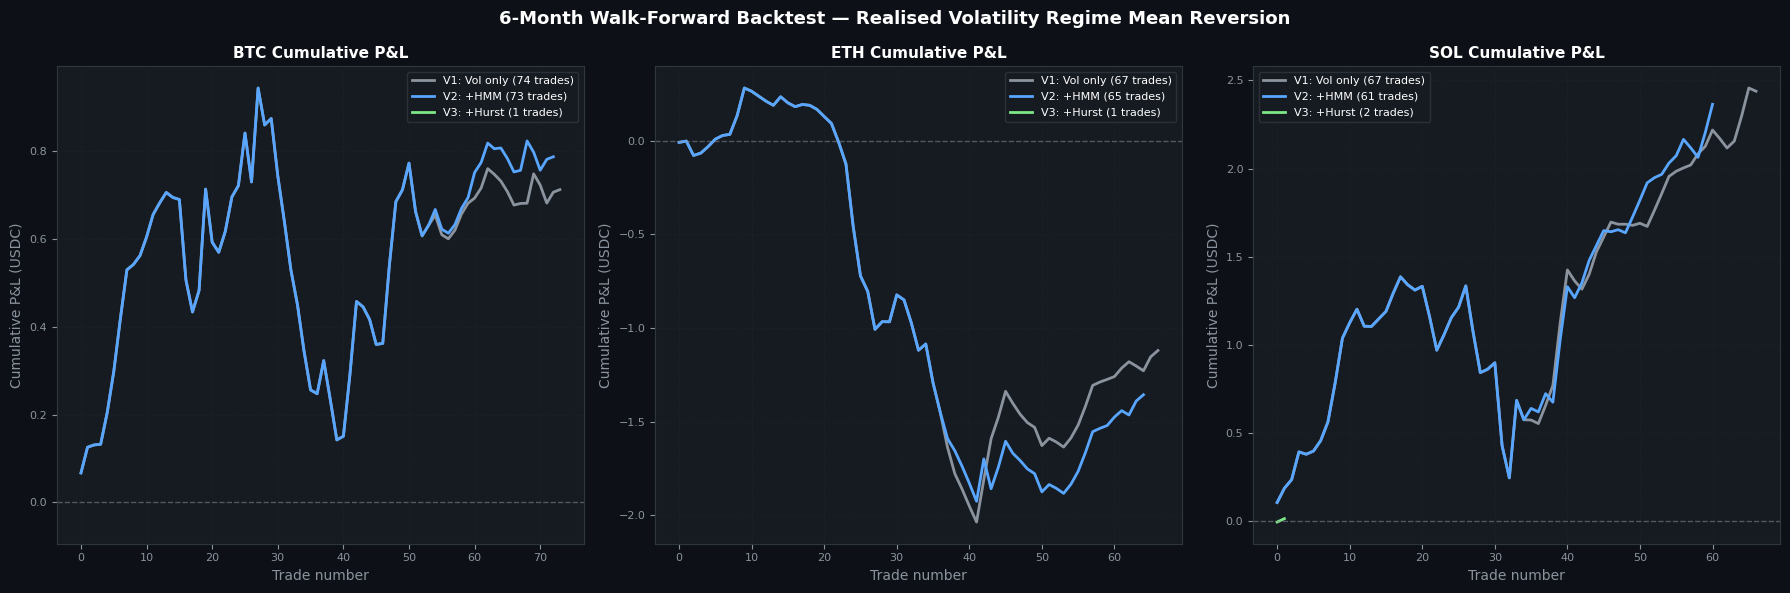

Saved as vol_backtest_results.png


In [8]:
# =============================================================================
# CHARTS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

for idx, (coin, df) in enumerate([('BTC', btc_df), ('ETH', eth_df), ('SOL', sol_df)]):
    
    direction_thresh = float(df['price_direction'].abs().quantile(0.80))
    
    t1 = run_vol_backtest(df, direction_thresh=direction_thresh,
                          use_hmm=False, use_hurst=False, train_days=30, test_days=10)
    t2 = run_vol_backtest(df, direction_thresh=direction_thresh,
                          use_hmm=True, use_hurst=False, train_days=30, test_days=10)
    t3 = run_vol_backtest(df, direction_thresh=direction_thresh,
                          use_hmm=True, use_hurst=True, train_days=30, test_days=10)
    
    ax = axes[idx]
    ax.set_facecolor('#161b22')
    ax.tick_params(colors=GREY, labelsize=8)
    ax.grid(True, alpha=0.15, color='#30363d', linestyle='--')
    for spine in ax.spines.values():
        spine.set_color('#30363d')
    
    for trades, color, label in [
        (t1, GREY,  f"V1: Vol only ({len(t1)} trades)"),
        (t2, BLUE,  f"V2: +HMM ({len(t2)} trades)"),
        (t3, GREEN, f"V3: +Hurst ({len(t3)} trades)"),
    ]:
        if not trades.empty:
            cumulative = np.cumsum(trades['total_pnl'].values)
            ax.plot(range(len(cumulative)), cumulative,
                    color=color, linewidth=2, label=label)
    
    ax.axhline(y=0, color=GREY, linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{coin} Cumulative P&L', color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trade number', color=GREY)
    ax.set_ylabel('Cumulative P&L (USDC)', color=GREY)
    ax.legend(fontsize=8, labelcolor='white', facecolor='#161b22', edgecolor='#30363d')

plt.suptitle('6-Month Walk-Forward Backtest — Realised Volatility Regime Mean Reversion',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vol_backtest_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Saved as vol_backtest_results.png')

## 8. Extract Calibrated Parameters for Gina Deployment

Once backtest results are reviewed, extract the optimal parameters
to use in the Gina plain English strategy description.

In [13]:
# =============================================================================
# EXTRACT GINA DEPLOYMENT PARAMETERS
# =============================================================================

# Use BTC as primary deployment asset
train_data = btc_df.iloc[:30*24]  # First 30 days as reference

rv_entry = train_data['rv_24h'].quantile(0.80)
rv_exit  = train_data['rv_24h'].quantile(0.60)
dir_thresh = float(btc_df['price_direction'].abs().quantile(0.80))

print("=== CALIBRATED PARAMETERS FOR GINA DEPLOYMENT ===")
print(f"Entry: RV above {rv_entry*100:.1f}% annualised (80th percentile)")
print(f"Exit:  RV drops below {rv_exit*100:.1f}% annualised (60th percentile)")
print(f"Direction filter: 4h price move > {dir_thresh*100:.2f}%")
print(f"Position size: 3 USDC")
print(f"Max exposure: 6 USDC")
print(f"Stop loss: 15%")
print(f"Time limit: 24 hours")

=== CALIBRATED PARAMETERS FOR GINA DEPLOYMENT ===
Entry: RV above 61.0% annualised (80th percentile)
Exit:  RV drops below 51.2% annualised (60th percentile)
Direction filter: 4h price move > 1.04%
Position size: 3 USDC
Max exposure: 6 USDC
Stop loss: 15%
Time limit: 24 hours


In [11]:
# Extract calibrated parameters for Gina
train_data = sol_df.iloc[:30*24]

rv_entry_80 = train_data['rv_24h'].quantile(0.80)
rv_entry_90 = train_data['rv_24h'].quantile(0.90)
rv_exit_60  = train_data['rv_24h'].quantile(0.60)
rv_exit_75  = train_data['rv_24h'].quantile(0.75)
dir_thresh  = float(btc_df['price_direction'].abs().quantile(0.80))

print(f"RV entry threshold (80th pct): {rv_entry_80*100:.1f}%")
print(f"RV entry threshold (90th pct): {rv_entry_90*100:.1f}%")
print(f"RV exit threshold  (60th pct): {rv_exit_60*100:.1f}%")
print(f"RV exit threshold  (75th pct): {rv_exit_75*100:.1f}%")
print(f"Direction threshold (80th pct): {dir_thresh*100:.2f}%")

RV entry threshold (80th pct): 98.4%
RV entry threshold (90th pct): 109.3%
RV exit threshold  (60th pct): 82.5%
RV exit threshold  (75th pct): 92.2%
Direction threshold (80th pct): 1.04%


## 9. Summary and Caveats

### Research connection

This strategy directly implements the findings from three prior projects:

**IV Regime Dashboard** — validated that high volatility regimes mean revert, with reversion 30-40% faster in HIGH regime than LOW regime. This strategy exploits exactly that finding on Hyperliquid perpetual data.

**HMM Dashboard** — the VolatilityHMM class here is a direct port of the Interactive Brokers live dashboard, now running on Hyperliquid candles. Same 3-state Gaussian emission model, same Bayesian update, same calibration from percentile segmentation.

**fBm Research** — the Hurst filter confirms anti-persistent regime before trading. H < 0.5 means the price series is structurally mean-reverting, providing theoretical justification for the trade.

### Honest caveats

**No funding income** — unlike the funding rate strategy, this strategy earns no funding payments while holding. Pure price mean reversion only.

**Direction threshold sensitivity** — the 4-hour price move threshold significantly affects trade frequency and quality. Tested at 80th percentile of historical moves.

**Transaction costs** — no slippage or fees modelled.

**Regime change risk** — strategy most vulnerable in sustained trending markets where high RV persists rather than reverting.

### Next steps

- Compare directly with funding rate strategy on same time period
- Test correlation between strategies — do they trigger simultaneously or complement each other?
- Model explicit transaction costs
- Explore combining both signals — high RV AND extreme funding simultaneously as strongest signal